# 🏙️ Land Use & Land Cover Change
## Arab 813 Hackathon — Planet Tanager Hyperspectral Explorer

This notebook uses **Planet's Tanager hyperspectral satellite** to map and characterise **urban expansion, land cover transitions, and impervious surface growth** in the Middle East and beyond.

---

## What You Will Learn

- How to load and combine scenes from two STAC collections (`urban` and `natural-lands`)
- How to compute indices that distinguish built-up areas, bare land, and vegetation
- How to visualize spectral differences between land cover classes

---

## Key Spectral Indices for Land Cover

| Index | Formula | Detects |
|-------|---------|---------|
| NDVI  | (NIR−Red)/(NIR+Red) | Vegetation |
| NDBI  | (SWIR−NIR)/(SWIR+NIR) | Built-up surfaces |
| MNDWI | (Green−SWIR)/(Green+SWIR) | Open water |
| BUI   | NDBI − NDVI | Net built-up (removes vegetation confusion) |

---

## Relevant STAC Collections

- **Urban:** `https://www.planet.com/data/stac/tanager-core-imagery/urban/collection.json`
- **Natural Lands:** `https://www.planet.com/data/stac/tanager-core-imagery/natural-lands/collection.json`


In [1]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

## Step 1 – Load the Urban Collection

We start with the **urban** collection which includes a Tanager scene over **Riyadh, Saudi Arabia** — one of the world's fastest-growing cities.


In [3]:
import requests

COLLECTION = "urban"
item_ids = ["20250407_035509_25_4001","20250515_080954_16_4001", "20250516_164837_16_4001", "20250412_111800_00_4001"]

base = f"https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}"
items = []
for iid in item_ids:
    url = f"{base}/{iid}/{iid}.json"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    items.append(r.json())
print(f"Loaded {len(items)} items from {COLLECTION}")

item = items[0]   # work with the first scene

/Users/vincentmarkiet/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded 4 items from urban


## Step 2 – Scene Metadata & Thumbnail

Let's see where our scene is before processing any data.


In [4]:
from IPython.display import Image
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])
Image(url=item["assets"]["thumbnail"]["href"])

Scene ID: 20250407_035509_25_4001
Date    : 2025-04-07T03:55:09.265846Z
Bbox    : [106.56597038950946, 10.586277284470714, 106.77946758310465, 10.77718728721292]


In [5]:
import json
print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 1,
  "collection_mode": "maximum_sensitivity",
  "constellation": "Tanager",
  "datetime": "2025-04-07T03:55:09.265846Z",
  "description": "All data products from Tanager-1 for 20250407_035509_25_4001 near X\u00e3 B\u00ecnh H\u01b0ng, Ho Chi Minh City, Vietnam",
  "gsd": 33.22,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 8,
  "location_description": "X\u00e3 B\u00ecnh H\u01b0ng, Ho Chi Minh City, Vietnam",
  "notes": null,
  "platform": "Planet",
  "plume_provider_ids": null,
  "quality_category": "standard",
  "title": "TanagerScene 20250407_035509_25_4001 Core Imagery",
  "view:azimuth": 77.6,
  "view:off_nadir": 4.3,
  "view:sun_azimuth": 103,
  "view:sun_elevation": 74.7
}


## Step 3 – Interactive Map

Visualize the scene extent and the RGB visual layer.


In [6]:
import leafmap, geopandas as gpd
from shapely.geometry import box

m = leafmap.Map(zoom=8)
ib = item["bbox"]
m.fit_bounds([[ib[1], ib[0]], [ib[3], ib[2]]])

# Scene footprint
gdf = gpd.GeoDataFrame({"geometry": [box(*ib)]}, crs="EPSG:4326")
m.add_gdf(gdf, layer_name="Scene footprint", style={"color":"yellow","fillOpacity":0})

# Visual COG overlay
for vk in ["ortho_visual", "visual", "rendered_preview"]:
    if vk in item.get("assets", {}):
        m.add_cog_layer(item["assets"][vk]["href"],
                        name=item["id"]+" (visual)",
                        titiler_endpoint="https://titiler.xyz")
        break

m

Map(center=[106.67273515628344, 10.681819556324493], controls=(ZoomControl(options=['position', 'zoom_in_text'…

## Step 4 – Download Surface Reflectance

Surface reflectance (SR) is the physically correct product for land cover analysis. The atmospheric correction removes sun-angle and haze effects so the same material always shows the same spectral signature regardless of when it was imaged.


In [7]:
import os, requests

sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR asset:", sr_key)
print("URL:", sr_url)

local_path = os.path.basename(sr_url)
if not os.path.exists(local_path):
    print("Downloading… (may take a few minutes)")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as fout:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    fout.write(chunk)
    print("Saved to:", local_path)
else:
    print("Already downloaded:", local_path)

Using SR asset: ortho_sr_hdf5
URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250407_035509_25_4001_ortho_sr_hdf5.h5
Already downloaded: 20250407_035509_25_4001_ortho_sr_hdf5.h5


## Step 5 – Quality Masks


In [27]:
import h5py, numpy as np

# Planet Tanager comes with several quality masks that we can use to check the data quality.
# let's mask out unwanted pixels such as clouds, no-data values, or delicate cirrus clouds

root = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(local_path, "r") as f:
    cloud  = f[f"{root}/beta_cloud_mask"][:]
    nodata = f[f"{root}/nodata_pixels"][:]
    cirrus = f[f"{root}/beta_cirrus_mask"][:]

# IMPORTANT!!!!!! - if you get gaps in your land cover classification results check the quality masks

valid = (cloud == 0) # (nodata == 0) & (cloud == 0) # & (cirrus == 0)
print(f"Valid pixels: {valid.mean()*100:.1f}%")
print(f"Cloud cover:  {(cloud!=0).mean()*100:.1f}%")

Valid pixels: 99.5%
Cloud cover:  0.5%


## Step 6 – Extract spectral wavelengths


In [28]:
# Extract spectral wavelengths from STAC metadata.
# The key is "bands" and wavelengths are in micrometers under "eo:center_wavelength".
bands_meta = item["assets"][sr_key].get("bands", [])
spectral_bands = [b for b in bands_meta iTjiraf "eo:center_wavelength" in b]
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0   # micrometers -> nanometers

print("Number of spectral bands:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last  10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last  10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


## Step 7 – Select key wavelengths for land cover

We need green, red, NIR, and SWIR for the standard land cover indices.


In [29]:
import numpy as np
def pick_band(target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    print(f"  Target {target_nm} nm → band {idx} ({wavelengths_nm[idx]:.1f} nm)")
    return idx, wavelengths_nm[idx]

print("Selecting bands:")
idx_green, _ = pick_band(560)
idx_red,   _ = pick_band(665)
idx_nir,   _ = pick_band(830)
idx_swir,  _ = pick_band(1610)

Selecting bands:
  Target 560 nm → band 37 (560.8 nm)
  Target 665 nm → band 58 (665.9 nm)
  Target 830 nm → band 91 (831.2 nm)
  Target 1610 nm → band 246 (1607.7 nm)


## Step 8 – Load bands


In [30]:
import h5py

root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    R_green = sr[idx_green, :, :].astype("float32")
    R_red   = sr[idx_red,   :, :].astype("float32")
    R_nir   = sr[idx_nir,   :, :].astype("float32")
    R_swir  = sr[idx_swir,  :, :].astype("float32")

for arr in [R_green, R_red, R_nir, R_swir]:
    arr[~valid] = np.nan
    arr[arr < 0] = np.nan

## Step 9 – Compute Land Cover Indices

### NDVI — Vegetation
High NDVI → parks, irrigated areas. Very low or negative → asphalt, concrete, desert.


In [31]:
eps = 1e-6
NDVI  = (R_nir - R_red)   / (R_nir + R_red   + eps)

### NDBI — Normalized Difference Built-Up Index
**Formula:** `(SWIR − NIR) / (SWIR + NIR)`

High values (positive) → built-up surfaces like roads, rooftops, concrete.
Low values (negative) → vegetation.

This is the key index for detecting urban areas.


In [32]:
NDBI  = (R_swir - R_nir)  / (R_swir + R_nir  + eps)

### MNDWI — Modified Normalized Difference Water Index
**Formula:** `(Green − SWIR) / (Green + SWIR)`

High values → rivers, reservoirs, irrigation canals. Useful for separating water from urban areas.


In [33]:
MNDWI = (R_green - R_swir) / (R_green + R_swir + eps)

### BUI — Built-Up Index
**Formula:** `NDBI − NDVI`

Subtracting vegetation removes confusion between dense canopy (parks) and built-up surfaces.
High positive BUI → urban core. Near zero → bare soil/desert. Negative → vegetated.


In [34]:
BUI   = NDBI - NDVI

## Step 10 – Visualize


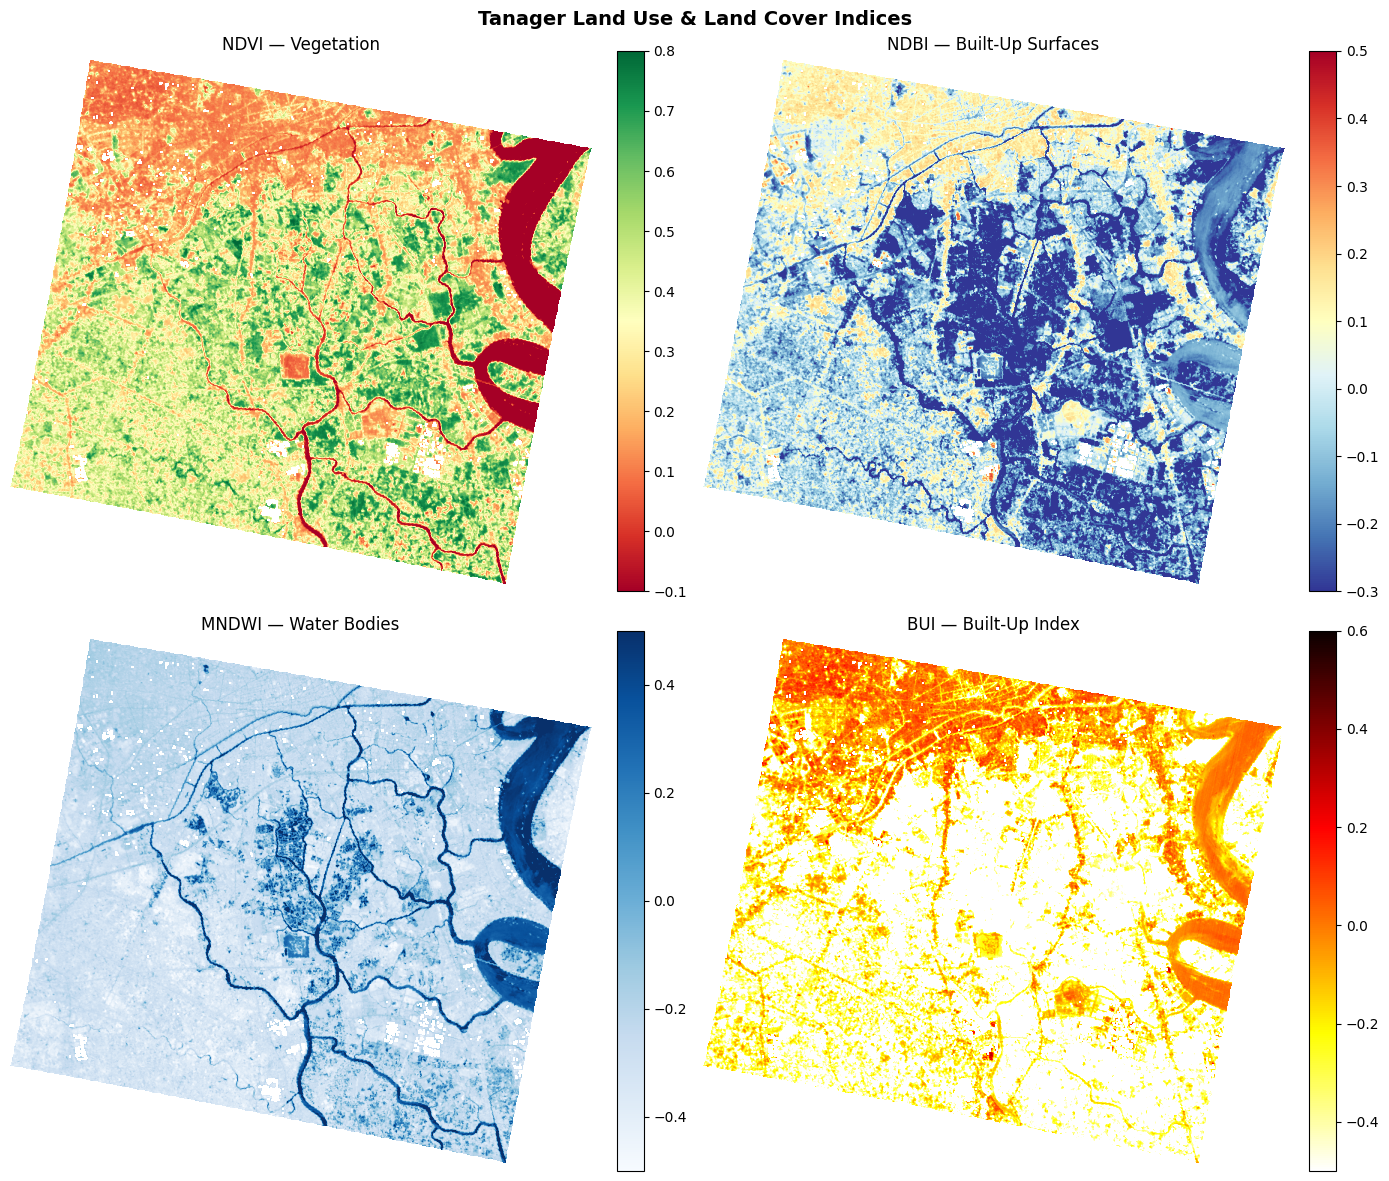

In [ ]:
import matplotlib.pyplot as plt


# IMPORTANT!!!!!! - if you get gaps in your land cover classification results check the quality masks

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0,0].imshow(NDVI,  cmap="RdYlGn",   vmin=-0.1, vmax=0.8)
axes[0,0].set_title("NDVI — Vegetation"); axes[0,0].axis("off")
plt.colorbar(im1, ax=axes[0,0], fraction=0.046, pad=0.04)

im2 = axes[0,1].imshow(NDBI,  cmap="RdYlBu_r", vmin=-0.3, vmax=0.5)
axes[0,1].set_title("NDBI — Built-Up Surfaces"); axes[0,1].axis("off")
plt.colorbar(im2, ax=axes[0,1], fraction=0.046, pad=0.04)

im3 = axes[1,0].imshow(MNDWI, cmap="Blues",     vmin=-0.5, vmax=0.5)
axes[1,0].set_title("MNDWI — Water Bodies"); axes[1,0].axis("off")
plt.colorbar(im3, ax=axes[1,0], fraction=0.046, pad=0.04)

im4 = axes[1,1].imshow(BUI,   cmap="hot_r",     vmin=-0.5, vmax=0.6)
axes[1,1].set_title("BUI — Built-Up Index"); axes[1,1].axis("off")
plt.colorbar(im4, ax=axes[1,1], fraction=0.046, pad=0.04)

plt.suptitle("Tanager Land Use & Land Cover Indices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 11 – Simple Land Cover Classification

We use thresholds to assign each pixel to a land cover class.
This is a simplified classification — real LULC mapping uses machine learning,
but this gives a useful first pass.


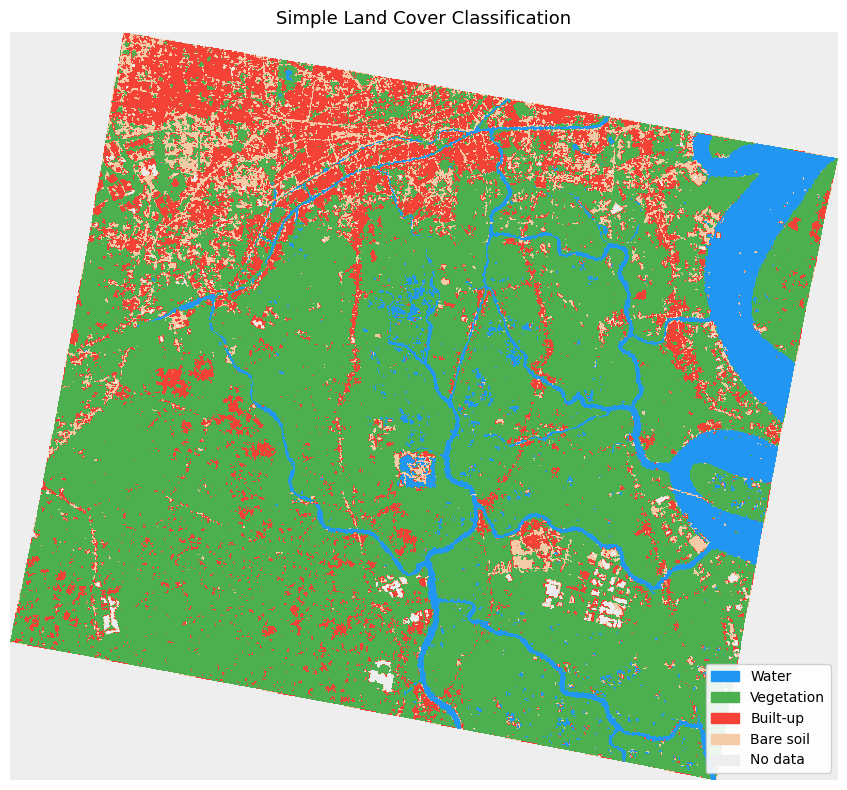


Pixel counts:
  Water: 34,456 (6.4%)
  Vegetation: 271,943 (50.2%)
  Built-up: 59,037 (10.9%)
  Bare soil: 27,504 (5.1%)
  No data: 148,460 (27.4%)


In [36]:
import numpy as np

lc = np.full(NDVI.shape, 4, dtype=np.uint8)   # 4 = unclassified/nodata
lc[MNDWI > 0.1]  = 0   # Water
lc[NDVI  > 0.2]  = 1   # Vegetation
lc[NDBI  > 0.1]  = 2   # Built-up
lc[(NDBI <= 0.1) & (NDVI <= 0.2) & (MNDWI <= 0.1)] = 3  # Bare soil / desert

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cmap = ListedColormap(["#2196F3", "#4CAF50", "#F44336", "#F5CBA7", "#EEEEEE"])
labels = ["Water", "Vegetation", "Built-up", "Bare soil", "No data"]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(lc, cmap=cmap, vmin=0, vmax=4)
ax.set_title("Simple Land Cover Classification", fontsize=13)
ax.axis("off")
handles = [Patch(color=c, label=l) for c, l in zip(cmap.colors, labels)]
ax.legend(handles=handles, loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

classes, counts = np.unique(lc[valid], return_counts=True)
names = dict(enumerate(labels))
print("\nPixel counts:")
for c, n in zip(classes, counts):
    print(f"  {names.get(c,'?')}: {n:,} ({n/valid.sum()*100:.1f}%)")

## Step 12 – Mean Spectrum per Class

One of the most powerful features of hyperspectral data: every class has a unique spectral fingerprint.


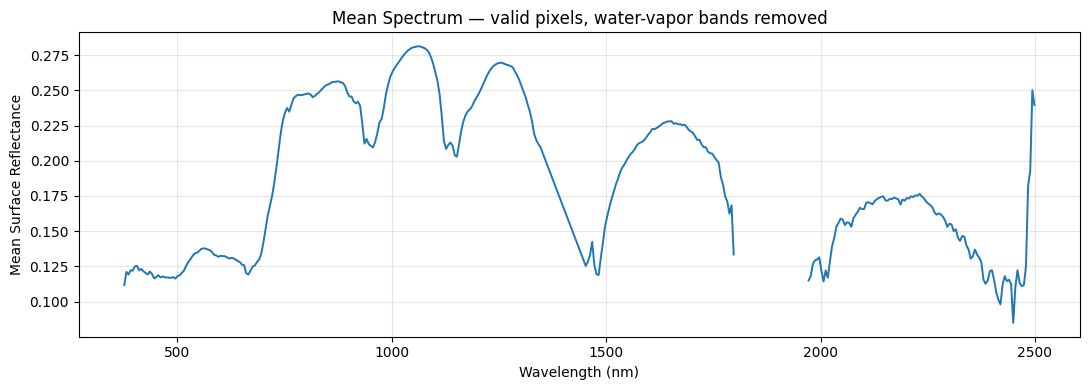

In [37]:
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

stride = 8
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
    cube = sr[good_idx, ::stride, ::stride].astype("float32")
    mask = valid[::stride, ::stride]
    cube[:, ~mask] = np.nan
    cube[cube < 0] = np.nan
    mean_spec = np.nanmean(cube, axis=(1,2))

import matplotlib.pyplot as plt
wls = [wavelengths_nm[i] for i in good_idx]
plt.figure(figsize=(11,4))
plt.plot(wls, mean_spec, lw=1.4)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Mean Spectrum — valid pixels, water-vapor bands removed")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 🚀 Hackathon Challenge Ideas

- **Urban growth modelling** — compare Tanager scenes across different dates to quantify urban expansion
- **Green space mapping** — map irrigated parks and green corridors in the urban scene
- **Heat island proxy** — NDBI correlates with urban heat; combine with weather data
- **Informal settlement detection** — spectral signatures of different roofing materials

> 📖 Created by: [LInkedin: Dr. Vincent Markiet - Space42](https://www.linkedin.com/in/vincentmarkiet/) 

> 📖 Data license: CC-BY-4.0 © Planet Labs PBC
